# Norwegian Folk Dancing Lesson Plots

For laughter and dance paper. 

Compose plots of hjeart rate, accelerometers, motion conditions and laughter annotations. 

Audio and Video not public. Event and timing information in this repo's datain folder.

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa
from scipy import interpolate

In [2]:
%load_ext autoreload
%autoreload 1
%aimport eq
%aimport mh
%aimport viz

In [3]:
 %reload_ext autoreload

# Import data constellation

In [4]:
part_dets =  pd.read_csv('../FolkDance/Participants/background.csv',index_col=0)
Row_Order = ['PC705', 'LS401', 'AU813', 'LS402', 'AU807', 'WW504', 'WW501',
       'WW507', 'AU806', 'LS406', 'AU809', 'AU811', 'WW509'] #, 'VN203'
part_dets.loc[Row_Order,'What is your experience with Norwegian Folk Dancing in particular?']

# # Called dance
# called_sections = {'Experienced':['LS401','WW504','LS406','AU809'],
#            'Familiar':['PC705','LS402','WW507','WW509','AU806','WW501'],
#            'Unfamiliar':['AU813','AU807','AU811']} #    ,'AU826','AU819',]}
# # Dancer
# dancer_sections = {'Dancers':['WW504','AU811','AU809','WW501','LS401'],
#            'Casual dancers':['AU813','LS402','LS406','WW509'],
#            'Non-dancers':['PC705','AU807','WW507','AU806']} 

PartID
PC705    Have never participated in such activities before
LS401       Trained to perform and/or compete in the style
AU813    Have participated in one or more events at an ...
LS402    Have participated in one or more events at an ...
AU807    Have never participated in such activities before
WW504    Have participated in one or more events at an ...
WW501    Have never participated in such activities before
WW507    Have never participated in such activities before
AU806    Have never participated in such activities before
LS406    Have never participated in such activities before
AU809    Have never participated in such activities before
AU811                Have attended some classes and events
WW509    Have participated in one or more events at an ...
Name: What is your experience with Norwegian Folk Dancing in particular?, dtype: object

In [6]:
# Norwegian folk dance
folk_sections = {'Experienced':['LS401','AU811'],
           'Familiar':['AU813','LS402','WW504','WW509'],
           'Unfamiliar':['PC705','AU807','WW501','WW507','AU806','LS406','AU809']} #    ,'AU826','AU819',]}

collist = Row_Order

section_pallet = {'Experienced':[0.5,0.5,0.5], 'Familiar':[0.2,0.2,0.2], 'Unfamiliar':'k'}
sect_tags = list(folk_sections.keys())

Event = 'FolkDancing'
audio_loc ='../FolkDance/AV/Audio_exp/'
phys_dir ='../FolkDance/Equivital/'
misc_loc = './datain/'
plot_loc = './plots/'

# Event annotations
Event_timings  = pd.read_csv(misc_loc+'Folk_Dancing_Events_Tidied.csv')
instruction_timings = Event_timings.query('Trial_Type=="Instruction"').copy()
instruction_timings.reset_index(inplace=True,drop=True)
Event_timings.loc[:,'Time'] = Event_timings.loc[:,'TIME'].astype('int')
events_types = ['Verbal','Instruction', 'Demo','Practice','Music','Applause']
eventType_pallet=dict(zip(events_types,['#eddca5','#eddca5','#c99b38','#8fb7b7','#00b0be','#ca65be']))
eventType_hatching=dict(zip(events_types,['x','x','*','.',None,'\\']))

dancings = Event_timings.query('Trial_Type in @events_types').copy()
dancings['DURATION'] = dancings['Dur']
dancings=dancings.query('Structure!="X"').copy()
dancings['Title']=dancings['LABEL']
dancings['LABEL']=dancings['Structure'] 


laughs = pd.read_csv(misc_loc+'Folk_Dance_Laughter_notes.csv')
laughs['Difficulty'] = laughs['Communicating difficulty']  # Communicating difficulty level (label: difficulty level) Communicating difficulty
laughs['Novelty'] =  laughs['Novelty and Surprise']
laughs['Negotiation'] =  laughs['Negociation']
laughs['Other'] = laughs['External']
laughs['InChatter'] = laughs['In Chatter']
who_hatch = { 'solo':'\\','few':'xx', 'subset':'xx','group':None}

whats = ['Mistake','Negotiation','Difficulty','Novelty','Joyful','Joke','Other','InChatter']
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))

In [7]:
df_files = pd.DataFrame(columns=['PartID','NID','Performance','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir+'Events/'):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==3:
                    df_files.loc[k,:] = {'PartID':dets[0],'NID':int(dets[0][2:5]),'Performance':'ChristmasParty','Segment':dets[1],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()
subfiles = df_files

## Load time series

In [12]:
df_allfeats={}
# Audio
aud_file = audio_loc + 'FolkDancing_w3_4800.mp3'
y, sr = librosa.load(aud_file)
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)

buff = 0 # no buffer for this audio
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
df_allfeats['Audio_cqt'] = C_df.copy()

sect_tags = list(folk_sections.keys())
time_c = 'c_sTime'
concert = 'ChristmasParty'
piece = 'Dancing'
ylabs = ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']#,'normHR1bt','HR10bt','HRV10bt_ar','Respwave','Respdiff','Audio']

s_time = -10
e_time = Event_timings['TIME'].iloc[-1]
sf = 20
altT = np.arange(s_time,e_time ,1/sf) #down sampling to 20Hz
time_s = altT 
df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
all_sigs = {}
for t in ['ACC_QoM']: all_sigs[t] = df.copy()

for i,row in PhysFiles.query('Signal=="ACC" and Segment == @piece').iterrows():
    if row['PartID'] in Row_Order: 
        V = pd.read_csv(row['FileLoc'],skipinitialspace=True)
        temp_df = pd.DataFrame(index=altT)
        times = V[time_c]
        for c in ['Vert Accelerometer','Lat Accelerometer','Long Accelerometer']:
            f = interpolate.interp1d(times,V['Vert Accelerometer'].rolling(int(256/sf)).mean(),kind = 'linear')    
            temp_df.loc[:,c] = f(altT)
        all_sigs['ACC_QoM'].loc[:,row['PartID']] =  np.sqrt(np.square(temp_df.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1))
# handling a distracting anomali
all_sigs['ACC_QoM'].loc[59.45:60.95,'AU811'] = all_sigs['ACC_QoM'].loc[59.45:60.95,'AU811'].min() 

df_allfeats['ACC_QoM'] = all_sigs['ACC_QoM'].copy()

# heart rate
df_feats = pd.DataFrame(index = time_s,columns = collist)
sig = 'normHR1bt'
for partID in Row_Order:
    row = subfiles.query('PartID==@partID and Measure=="altEQCIBI" and Segment == @piece').iloc[0]
    V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
    if len(V)>10:
        sig_t = V['c_sTime']
        sig_v = V['Interbeat Interval (MS)']
        IBI = mh.clean_IBI(sig_t,sig_v,activitytype='default')
        HR = mh.ibi_feats(IBI.index,IBI.IBI.values,time_s)
        df_feats.loc[:,partID] = HR[sig].values

df_allfeats[sig] = df_feats.copy()

df_smoothed = df_allfeats['normHR1bt'].copy()
for partID in Row_Order:
    HR = df_smoothed[partID]
    cutHR = HR[HR.notna()]
    cutT = HR[HR.notna()].index
    f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
    df_smoothed[partID] = f(df_smoothed.index)
df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 

df_allfeats['normHR1bt_smoothed'] = df_smoothed.copy()


In [13]:
s_time = 0
e_time = 773.317370 	

Event_timings['DURATION'] = Event_timings['Dur']
sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.Trial_Type.unique())
events_types = ['Verbal','Instruction', 'Demo','Practice','Music','Applause']
eventType_pallet=dict(zip(events_types,['#eddca5','#eddca5','#c99b38','#8fb7b7','#00b0be','#ca65be']))
eventType_hatching=dict(zip(events_types,['x','x','*','.',None,'\\']))
sections = folk_sections
sect_tags= list(sections.keys())


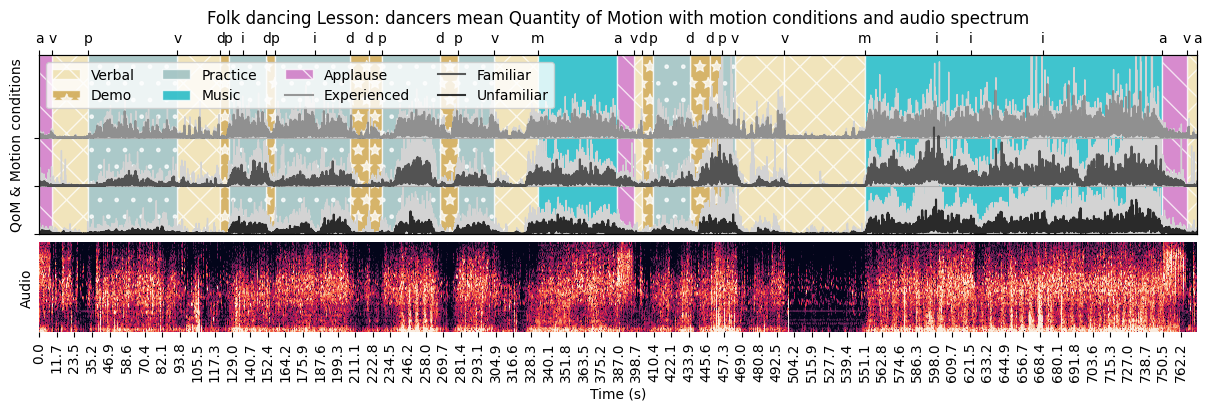

In [14]:

fig3 = plt.figure(constrained_layout=True,figsize=(12,4))
gs = fig3.add_gridspec(3, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2, :])

ax=axes[0]
for ev in ['Verbal','Demo','Practice','Music','Applause']: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.75,label=ev)
for ev in eventType_pallet.keys():
        viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.75)
df_feat =  df_allfeats['ACC_QoM'].astype('float')
x = df_feat.index

shift_d = 1000
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    y_minimum = df_feat[sections[sect]].quantile(0.1,axis=1)
    y_maximum = df_feat[sections[sect]].quantile(0.9,axis=1)
    fill = ax.fill_between(x, y_minimum-sect_i*shift_d, y_maximum-sect_i*shift_d, color="lightgrey")
    ax.plot(df_feat[sections[sect]].median(axis=1)-sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
ax.legend(ncol=4,loc='upper left')
ax.set(yticklabels=[],ylabel='QoM & Motion conditions') 
ax.grid()
ax.set_title('Folk dancing Lesson: dancers mean Quantity of Motion with motion conditions and audio spectrum')

ax.set(xlim = [s_time,e_time],ylim = [-2*shift_d,1.7*shift_d],xticks=[],yticks=[0,-shift_d,-shift_d*2])
ax1 = ax.twiny()
ax1.set(xticks = dancings.loc[:,'TIME'],xticklabels=dancings.loc[:,'LABEL'].str[0],xlim = [s_time,e_time])

ax=axes[1] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./plots/Fig3_FolkDancing_Timeline.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Laughter and Heart Rate plot with Annotations¶

In [15]:
# Annotations = pd.DataFrame(columns=['x','y','text','textpar'])
An = []
An.append({'x':16,'y':0.4,'text':'A','xytext':(-10, 20)})
An.append({'x':34,'y':0.3,'text':'B','xytext':(-10, 20)})
An.append({'x':230,'y':0.4,'text':'C','xytext':(-25, 10)})
An.append({'x':280,'y':0.5,'text':'D','xytext':(-25, 10)})
An.append({'x':469,'y':0.45,'text':'E','xytext':(-25, 10)})
An.append({'x':599,'y':0.7,'text':'F','xytext':(-25, 10)})
An.append({'x':610,'y':0.9,'text':'G','xytext':(-25, 10)})
Annotations = pd.DataFrame(An)

In [16]:
sect_tags = list(sections.keys())
eventType_pallet.keys()

dict_keys(['Verbal', 'Instruction', 'Demo', 'Practice', 'Music', 'Applause'])

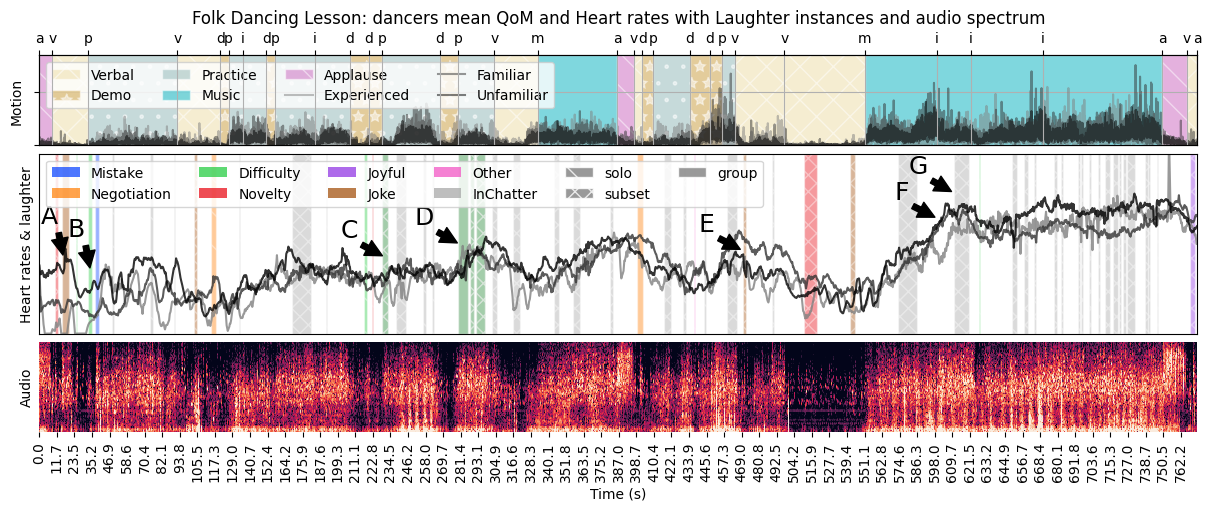

In [17]:
Event_timings['DURATION'] = Event_timings['Dur']
sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
sub_eventTypes = list(sub_events.Trial_Type.unique())

sect_tags = list(sections.keys())

fig3 = plt.figure(constrained_layout=True,figsize=(12,5))
gs = fig3.add_gridspec(4, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0, :])
axes[1] = fig3.add_subplot(gs[1:3, :])
axes[2] = fig3.add_subplot(gs[3, :])

ax=axes[0]
for ev in ['Verbal','Demo','Practice','Music','Applause']: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
df_feat =  df_allfeats['ACC_QoM'].astype('float')
x = df_feat.index

shift_d = 1000
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)-sect_i,color =section_pallet[sect],alpha=0.5,label=sect )
ax.legend(ncol=4,loc='upper left')
ax.set(yticklabels=[],ylabel='Motion') 
ax.grid()
ax.set_title('Folk Dancing Lesson: dancers mean QoM and Heart rates with Laughter instances and audio spectrum')

ax.set(xlim = [s_time,e_time],ylim = [0,1.7*shift_d],xticks=[])
ax1 = ax.twiny()
ax1.set(xticks = dancings.loc[:,'TIME'],xticklabels=dancings.loc[:,'LABEL'].str[0],xlim = [s_time,e_time])
ax1.grid()

ax=axes[1]
A = laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
for who in ['solo','subset','group']:
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
ax.legend(ncol=6,loc='upper left')

df_feat =  df_allfeats['normHR1bt'].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_smoothed[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(xlim = [s_time,e_time],ylim = [-0.2,1.2],xticks=[],yticks=[])
ax.grid()
# ax.legend()
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset','few', 'group', 'solo']:
    sub_laughs = laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.4)

for i,row in Annotations.iterrows():
    ax.annotate(row['text'],xy=(row['x'],row['y']), xycoords='data',
            xytext=row['xytext'], textcoords='offset points', arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='center', verticalalignment='bottom', fontsize=18)      
        
ax=axes[2] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

plt.savefig('./plots/Fig6_FolkDancing_Laughter.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Quantified stats around laughter and dancing intervals

In [18]:
df_feat1 =  df_allfeats['ACC_QoM'].astype('float').copy()
df_feat2 =  df_allfeats['normHR1bt_smoothed'].astype('float').copy()

In [19]:
ets = ['Verbal','Demo','Practice','Music','Applause']
Event_Details = dancings.query('Trial_Type in @ets')
df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat1.columns))
A = []
for i,row in Event_Details.iterrows():
    k = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
QoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat1.columns))
A = []
k = df_feat1.mean()
for i,row in Event_Details.iterrows():
    K = df_feat1.loc[row['TIME']+4:row['TIME']+row['Dur']+4,:].mean() - df_feat1.loc[row['TIME']-2:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dQoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat2.columns))
A = []
for i,row in Event_Details.iterrows():
    k = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
nHR_even_means = pd.concat(A,axis=1).transpose()


df_phys=pd.DataFrame(columns = list(Event_Details.columns)+list(df_feat2.columns))
A = []
for i,row in Event_Details.iterrows():
    # K = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat2.loc[row['TIME']-5:row['TIME'],:].mean()
    K = df_feat2.loc[row['TIME']+4:row['TIME']+row['Dur']+4,:].mean() - df_feat2.loc[row['TIME']-2:row['TIME'],:].mean()

    A.append(pd.concat([row,K]))
dHR_even_means = pd.concat(A,axis=1).transpose()

Event_means = QoM_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_Mean")
Event_means["QoM_Mean"] = Event_means["QoM_Mean"].astype('float')
B = dQoM_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_dMean")
Event_means["QoM_dMean"] = B["QoM_dMean"].astype('float')
B = nHR_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_Mean")
Event_means["HR_Mean"] = B["HR_Mean"].astype('float')
B = dHR_even_means.melt(id_vars = Event_Details.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_dMean")
Event_means["HR_dMean"] = B["HR_dMean"].astype('float')
# Event_means

HR_Mean
  Source  ddof1  ddof2          F         p-unc       ng2       eps
0   TIME     26    312  13.045215  4.286473e-36  0.416714  0.145771


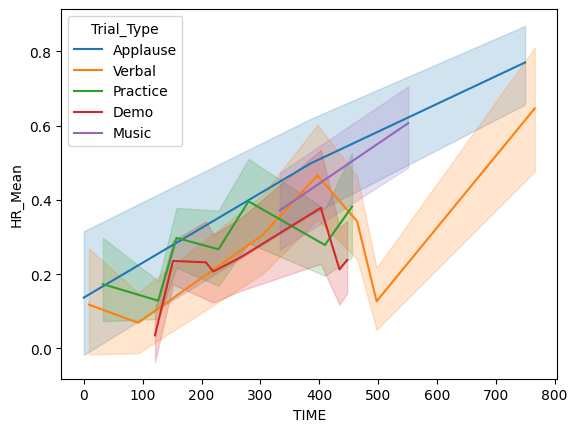

HR_dMean
  Source  ddof1  ddof2         F         p-unc       ng2       eps
0   TIME     26    312  9.558963  9.116557e-27  0.436321  0.210231


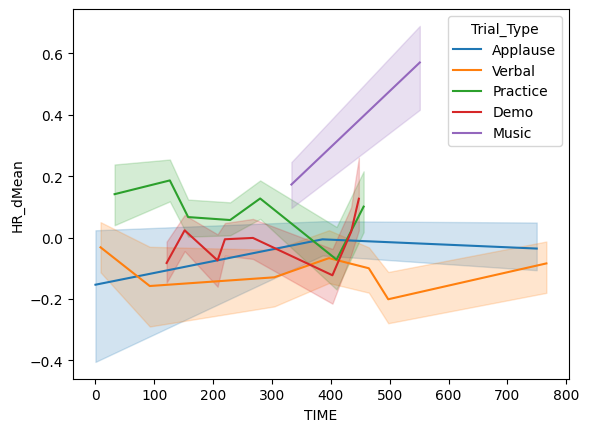

QoM_Mean
  Source  ddof1  ddof2          F         p-unc       ng2       eps
0   TIME     26    312  25.594939  3.111071e-62  0.615848  0.082693


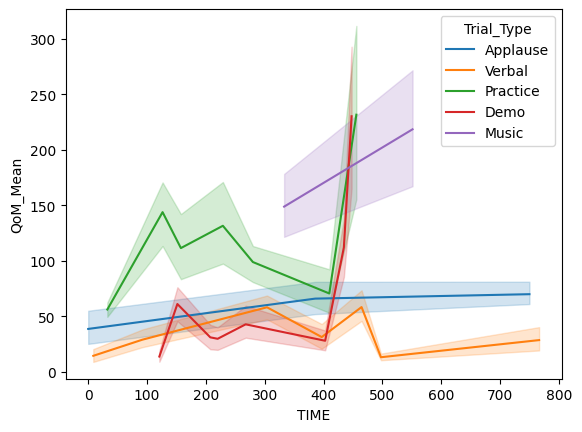

QoM_dMean
  Source  ddof1  ddof2          F         p-unc       ng2       eps
0   TIME     26    312  14.972683  8.642315e-41  0.550459  0.179585


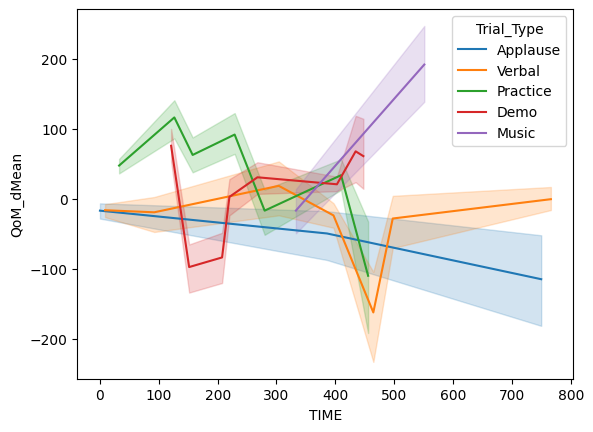

In [20]:
for depv in ["HR_Mean","HR_dMean","QoM_Mean","QoM_dMean"]:
    print(depv)
    print(pg.rm_anova(data = Event_means,dv = depv,subject = 'partID',within='TIME'))
    sns.lineplot(x="TIME", y=depv, hue="Trial_Type",data= Event_means) # hue="region", style="event",
    plt.show()

In [21]:
laughs['Dur'] = laughs['DURATION']

df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat1.columns))
A = []
for i,row in laughs.iterrows():
    k = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
QoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat1.columns))
A = []
k = df_feat1.mean()
for i,row in laughs.iterrows():
    
    K = df_feat1.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat1.loc[row['TIME']-5:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dQoM_even_means = pd.concat(A,axis=1).transpose()

df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat2.columns))
A = []
for i,row in laughs.iterrows():
    k = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean()
    A.append(pd.concat([row,k]))
nHR_even_means = pd.concat(A,axis=1).transpose()


df_phys=pd.DataFrame(columns = list(laughs.columns)+list(df_feat2.columns))
A = []
for i,row in laughs.iterrows():
    # K = df_feat2.loc[row['TIME']:row['TIME']+row['Dur'],:].mean() - df_feat2.loc[row['TIME']-5:row['TIME'],:].mean()
    K = df_feat2.loc[row['TIME']+4:row['TIME']+row['Dur']+4,:].mean() - df_feat2.loc[row['TIME']-2:row['TIME'],:].mean()
    A.append(pd.concat([row,K]))
dHR_even_means = pd.concat(A,axis=1).transpose()

Even_means = QoM_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_Mean")
Even_means["QoM_Mean"] = Even_means["QoM_Mean"].astype('float')
B = dQoM_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="QoM_dMean")
Even_means["QoM_dMean"] = B["QoM_dMean"].astype('float')
B = nHR_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_Mean")
Even_means["HR_Mean"] = B["HR_Mean"].astype('float')
B = dHR_even_means.melt(id_vars = laughs.columns, value_vars = df_feat1.columns,var_name="partID", value_name="HR_dMean")
Even_means["HR_dMean"] = B["HR_dMean"].astype('float')
# Even_means

In [22]:
laugh_means = Even_means.copy()
whos = ['subset','group']
sub_laugh_means = laugh_means.query('Who in @whos').copy()

In [23]:
pg.rm_anova(data = sub_laugh_means,dv = 'HR_Mean',subject = 'partID',within='Who')

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,Who,1,12,6.861504,0.022408,0.164973,1.0


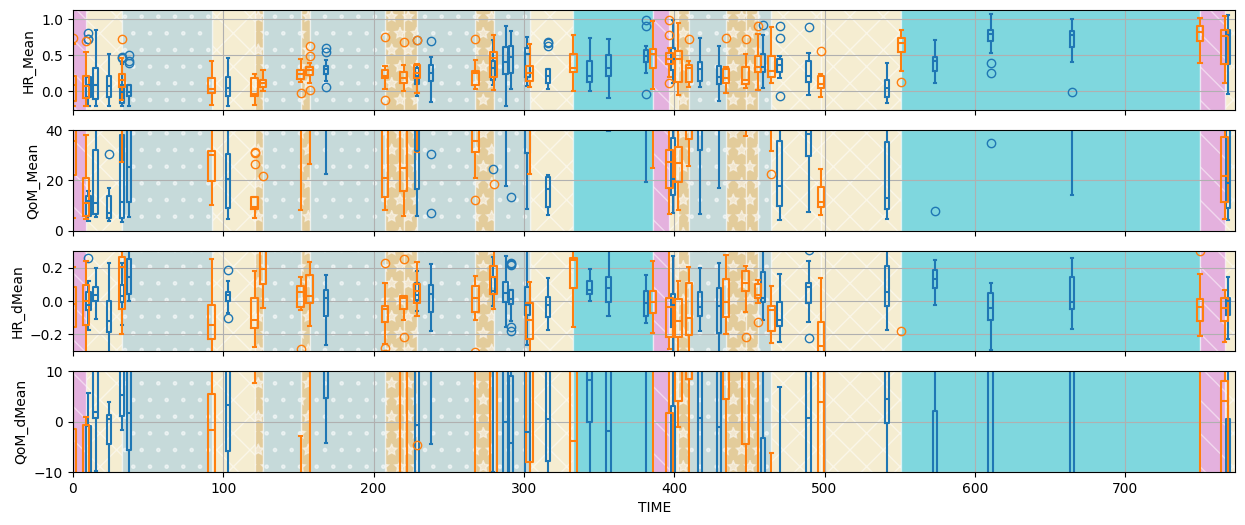

In [24]:
fig, axes = plt.subplots(4,1,sharex=True,figsize=(15,6))
ax = axes[0]
sns.boxplot(x='TIME', y='HR_Mean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='HR_Mean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
# ax.set(ylim=[0,50])
ax = axes[1]
ax = sns.boxplot(x='TIME', y='QoM_Mean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='QoM_Mean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
ax.set(ylim=[0,40])
ax = axes[2]
ax = sns.boxplot(x='TIME', y='HR_dMean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='HR_dMean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.grid()
ax.set(ylim=[-0.3,0.3])
ax = axes[3]
ax = sns.boxplot(x='TIME', y='QoM_dMean',data=sub_laugh_means,native_scale=True,fill=False,ax=ax)
sns.boxplot(x='TIME', y='QoM_dMean', data=Event_means,native_scale=True,fill=False,ax=ax)
for ev in eventType_pallet.keys(): viz.annat_shade(ax,Event_timings.query('Trial_Type==@ev'),eventType_pallet[ev],eventType_hatching[ev],0.5)
ax.set(ylim=[-10,10],xlim = [s_time,e_time])
ax.grid()
plt.savefig('./plots/Phys_Changes_FolkDancing.jpeg',bbox_inches = 'tight',dpi = mydpi)

plt.show()

# Laughter counts¶

In [25]:
laughs.value_counts('Who')

Who
subset    23
few       18
solo      13
group      5
Name: count, dtype: int64

In [26]:
Laugh_Counts = pd.DataFrame(index = whats, columns = events_types,data = 0)
for i,row in dancings.iterrows():
    s_time = row['StartTime']
    e_time = row['EndTime']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
    Laugh_Counts.loc[whats,row['Trial_Type']]+=sub_laughs.loc[:,whats].sum()

Laugh_Counts.columns

Index(['Verbal', 'Instruction', 'Demo', 'Practice', 'Music', 'Applause'], dtype='object')

In [27]:
print(Laugh_Counts[['Verbal','Demo', 'Practice', 'Music']].transpose().to_latex())

\begin{tabular}{lrrrrrrrr}
\toprule
 & Mistake & Negotiation & Difficulty & Novelty & Joyful & Joke & Other & InChatter \\
\midrule
Verbal & 0 & 2 & 1 & 2 & 1 & 4 & 0 & 4 \\
Demo & 0 & 1 & 2 & 1 & 0 & 0 & 1 & 2 \\
Practice & 1 & 0 & 5 & 0 & 0 & 0 & 0 & 17 \\
Music & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 22 \\
\bottomrule
\end{tabular}

